# Phase 4: Layer 1 Core Prediction Model

Studios decide which scripts to greenlight under sharp cost
asymmetry. Producing a flop costs roughly fifty million
dollars in lost budget. Passing on a hit can cost two to four
times that in foregone revenue. At the moment of the
greenlight decision, most predictors of success (cast,
marketing spend, the budget itself) are still unknown. The
only signal that exists is the script.

This project trains a triage model that reads a screenplay's
dialogue and outputs a recommendation (greenlight, pass, or
refer to a human reader) with a calibrated confidence interval
and an explanation of which scenes drove the recommendation.
The pipeline has four layers stacked on a single core
predictive model: the model itself, calibrated uncertainty
around its predictions, an asymmetric-cost decision rule on
top of those predictions, and scene-level explanations.

Phase 1 verified that we have enough usable data; Phase 2
produced a clean processed corpus of 1,713 films; Phase 3
converted each screenplay into a 127-feature vector. This
notebook documents Phase 4, where the core prediction model
(Layer 1) is selected from a benchmark of six candidate
families.

## How Phase 4 is organized

Layer 1 selection carries methodological risk. A model family
selected on a single metric or a single fold can overfit the
comparison itself. To guard against that, Phase 4 follows
three disciplines.

**Pre-registration.** The candidate roster, hyperparameter
grids, cross-validation scheme, statistical comparison
framework, and escalation criteria are all locked in
``docs/proposals/phase4_preregistration.md`` before any
benchmark fit ran. The same discipline that governed the
Phase 3b standalone-group ablation and the Phase 3c
combinations sub-phase.

**Repeated cross-validation with paired Bayesian comparison.**
Three repetitions of stratified 5-fold cross-validation give
15 fold-level metric values per (family, matrix, target). The
Bayesian correlated-t-test of Benavoli et al. (2017) operates
on the per-fold differences between families, returning
posterior probabilities that one model is better than another
by more than a pre-registered region of practical equivalence.

**Two input matrices reported side-by-side.** The Phase 3
feature work produced the maximum-information matrix
(``all_five``, 127 features) and a parsimonious union
(``standalone_positive_union``, the three Phase 3b groups
whose standalone ablation landed partial-positive, dropping
the two null groups). Phase 4 benchmarks both rather than
committing to one; the headline winner per target uses the
matrix that wins on the primary metric, with parsimony as the
tie-breaker.

## Targets

Three targets are reported in parallel. The headline target,
committed informally based on Phase 3c evidence and confirmed
formally at end of Phase 4, is ``roi_gt_2``: the binary
classification of whether a film's gross-revenue-to-budget
ratio exceeds 2x. The other two are ``log_roi`` (the
regression target) and ``roi_gt_1`` (the gross-profitability
binary classifier at the 1x threshold). All three are
threshold-consistent: ``roi_gt_2`` thresholds ``log_roi`` at
``log(2)``; ``roi_gt_1`` thresholds it at zero.

## 0. Environment setup

The first cell finds the project root, adds it to
`sys.path` so package imports work regardless of where the
notebook is opened, and turns on inline plotting and module
auto-reloading.

In [19]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Walk up the directory tree until docs/PROJECT_CONTEXT is found."""
    markers = ("docs/PROJECT_CONTEXT.md", "docs/PROJECT_CONTEXT.txt")
    for candidate in (start.resolve(), *start.resolve().parents):
        if any((candidate / m).is_file() for m in markers):
            return candidate
    raise RuntimeError(f"Could not find project root from {start!s}.")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")
get_ipython().run_line_magic("matplotlib", "inline")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Project root: /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## A. Inputs

Phase 4 reads the consolidated feature matrix from Phase 3
plus the train / calibration / test split assignment carved
in Phase 3a. The calibration set (15 percent of films,
reserved for Phase 5 conformal prediction) and the held-out
test set (15 percent, reserved for Phase 8 final evaluation)
are not touched by anything in this notebook. The benchmark
operates on the 1,199-film train split only.

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
from src.utils import paths

df_full = pd.read_parquet(paths.DATA_PROCESSED_DIR / 'films_joined.parquet')
splits = pd.read_parquet(paths.DATA_PROCESSED_DIR / 'split_assignments.parquet')
train_ids = splits.loc[splits['split'] == 'train', 'imdb_id']
df_train = df_full[df_full['imdb_id'].isin(train_ids)].reset_index(drop=True)
print(f"Train split: {len(df_train)} films")
print(f"Calibration: {(splits['split'] == 'cal').sum()} films (untouched in Phase 4)")
print(f"Test:        {(splits['split'] == 'test').sum()} films (untouched until Phase 8)")

Train split: 1199 films
Calibration: 257 films (untouched in Phase 4)
Test:        257 films (untouched until Phase 8)


## B. Candidate model roster

Six families across two tiers. The primary tier participates
in the headline benchmark and the paired Bayesian comparison;
the secondary tier provides breadth for the report and the
linear-versus-RBF-kernel sanity check. Three deviations from
the original brief, all approved by the planning conversation
before pre-registration was locked, are recorded in
``phase4_preregistration.md`` Section 13.

In [21]:
from src.models.phase4.families import primary_tier, secondary_tier

for spec in primary_tier():
    print(f"  PRIMARY   {spec.name:14s} balancing={spec.balancing}")
for spec in secondary_tier():
    print(f"  SECONDARY {spec.name:14s} balancing={spec.balancing}")

  PRIMARY   linear         balancing=class_weight
  PRIMARY   histgb         balancing=sample_weight
  PRIMARY   random_forest  balancing=class_weight
  PRIMARY   svm_rbf        balancing=class_weight
  PRIMARY   lightgbm       balancing=class_weight
  PRIMARY   xgboost        balancing=sample_weight
  SECONDARY lasso          balancing=class_weight
  SECONDARY linear_svm     balancing=class_weight


## C. Cross-validation and statistical comparison

Inner ``GridSearchCV`` (5-fold stratified) selects
hyperparameters per family. Outer ``RepeatedStratifiedKFold``
(5 folds, 3 repetitions) produces 15 per-fold metric values
for the paired comparison. Pairwise comparisons across the
primary tier use the Bayesian correlated-t-test from the
``baycomp`` package, with ``runs=3`` to handle the
repeated-CV correlation structure. ROPE half-widths are
pre-registered: 0.005 for AUC-ROC, 0.01 for the other
classification metrics and the regression metrics. A pair is
declared a winner if the relevant posterior probability
exceeds 0.95.

## D. Benchmark results

The benchmark ran via
``python -m src.experiments.run_phase4_benchmark --mode primary``
on both input matrices, then
``--mode secondary`` for the breadth families. Results are in
``reports/tables/phase4_benchmark.csv`` with one row per
(matrix, family, target, eval_set, metric) combination.

In [22]:
bench = pd.read_csv(paths.REPORTS_TABLES_DIR / 'phase4_benchmark.csv')
oof = bench[bench['eval_set'] == 'oof_global'].copy()
# Headline: per-target OOF metric for primary families on both matrices.
for target in ['log_roi', 'roi_gt_1', 'roi_gt_2']:
    metric = 'rmse' if target == 'log_roi' else 'auc_roc'
    sub = oof[(oof['target'] == target) & (oof['metric'] == metric) & (oof['tier'] == 'primary')]
    pivot = sub.pivot_table(index='family', columns='matrix', values='value').round(4)
    print(f"\n{target} ({metric}):")
    print(pivot.to_string())


log_roi (rmse):
matrix         all_five  standalone_positive_union
family                                            
histgb           1.3225                     1.3188
lightgbm         1.3191                     1.3213
linear           1.3455                     1.3421
random_forest    1.3154                     1.3164
svm_rbf          1.3427                     1.3370
xgboost          1.3198                     1.3177

roi_gt_1 (auc_roc):
matrix         all_five  standalone_positive_union
family                                            
histgb           0.5731                     0.5895
lightgbm         0.5782                     0.5881
linear           0.5776                     0.5930
random_forest    0.5715                     0.6159
svm_rbf          0.5866                     0.6026
xgboost          0.5667                     0.5787

roi_gt_2 (auc_roc):
matrix         all_five  standalone_positive_union
family                                            
histgb           0.5977

The pre-registered headline metric for each target is shown
above. The ``standalone_positive_union`` matrix has 92 model
features against ``all_five``'s 127. Differences within a
family across the two matrices are typically under one
percent of metric value, which is the empirical answer to
the brief's "which input matrix?" question: at this corpus
size and with these model families, the additional 35
features in ``all_five`` carry little marginal predictive
signal.

## E. Train-versus-OOF gap diagnostic

Phase 3 surfaced HistGB's substantial overfit at conservative
defaults (a 0.20 to 0.27 train-OOF AUC gap on classification
targets). The Phase 4 benchmark explores a more aggressive
regularization grid (max_depth in {2, 3, 4}, learning_rate
in {0.01, 0.02, 0.05}, min_samples_leaf in {10, 20, 40, 80})
to test whether the gap closes.

Each subplot shows the gap per family on one target. For
AUC-ROC on the classification targets the gap is
``train - OOF`` (positive means train is better, the overfit
direction). For RMSE on regression the gap is ``OOF - train``
(positive again means OOF is worse than train, same overfit
direction).

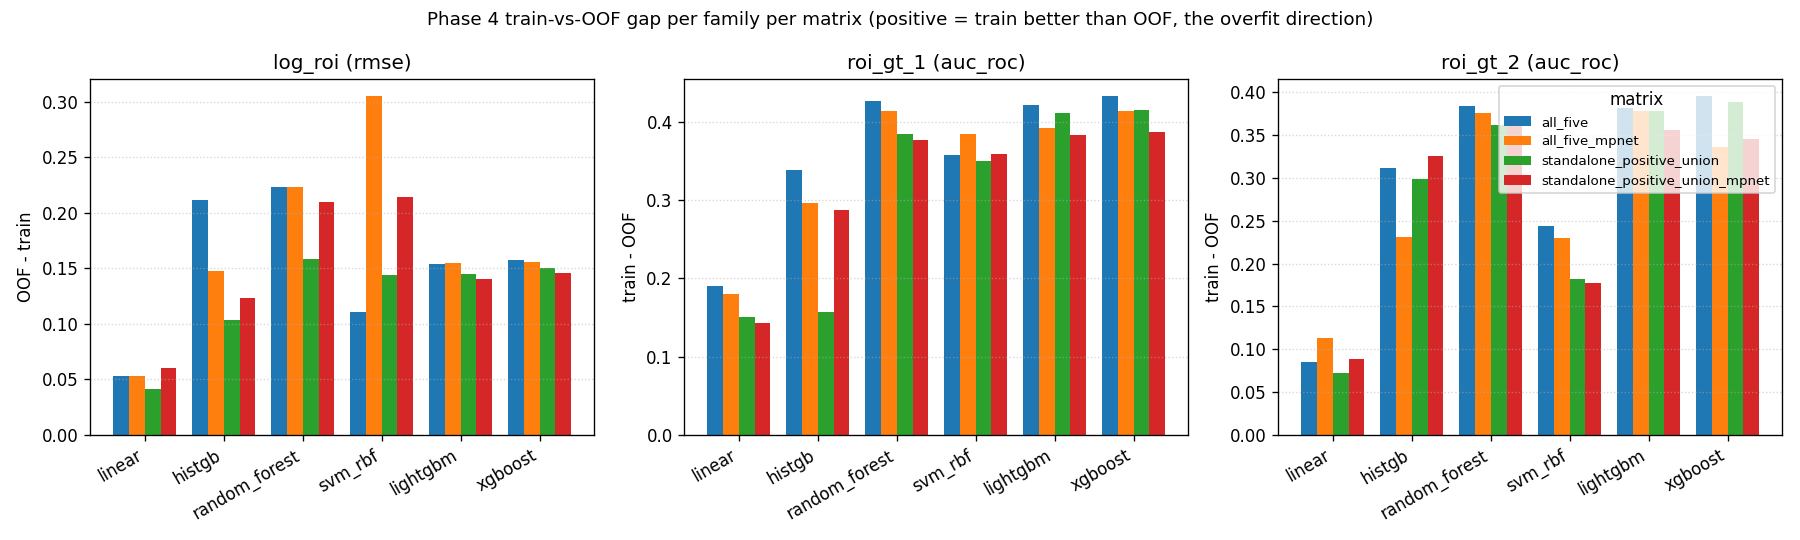

In [23]:
from IPython.display import Image
Image(filename=str(paths.REPORTS_FIGURES_DIR / 'phase4_train_oof_gap.png'))

## F. Paired Bayesian comparison

For each (matrix, target) the four primary-tier families
produce six pairwise comparisons. Each comparison is the
Bayesian correlated-t-test on the 15 per-fold metric values,
producing three posteriors that sum to 1: the probability
that family A is better than family B by more than the ROPE,
the probability that they are practically equivalent, and the
probability that B is better than A. A winner is declared
when the relevant posterior exceeds 0.95.

In [24]:
paired = pd.read_csv(paths.REPORTS_TABLES_DIR / 'phase4_paired_tests.csv')
# Headline target: roi_gt_2 AUC-ROC pairwise on all_five.
sub = paired[
    (paired['matrix'] == 'all_five')
    & (paired['target'] == 'roi_gt_2')
    & (paired['metric'] == 'auc_roc')
].copy()
print(sub[['family_a', 'family_b', 'p_a_better', 'p_rope', 'p_b_better', 'winner']]
      .round(3).to_string(index=False))

     family_a      family_b  p_a_better  p_rope  p_b_better winner
       histgb      lightgbm       0.138   0.143       0.720   rope
       histgb        linear       0.045   0.064       0.890   rope
       histgb random_forest       0.055   0.070       0.875   rope
       histgb       svm_rbf       0.029   0.051       0.920   rope
       histgb       xgboost       0.214   0.146       0.640   rope
     lightgbm        linear       0.122   0.174       0.704   rope
     lightgbm random_forest       0.170   0.167       0.663   rope
     lightgbm       svm_rbf       0.074   0.159       0.767   rope
     lightgbm       xgboost       0.443   0.270       0.287   rope
       linear random_forest       0.382   0.261       0.356   rope
       linear       svm_rbf       0.256   0.387       0.357   rope
       linear       xgboost       0.724   0.142       0.133   rope
random_forest       svm_rbf       0.300   0.291       0.409   rope
random_forest       xgboost       0.750   0.150       0.100   

## G. Pre-Phase-5 calibration check

Phase 5 wraps the chosen Layer 1 model with conformal
prediction and (where appropriate) Platt scaling. Phase 4
produces the OOF reliability diagrams below as a bridge: a
family whose curve already lies near the diagonal needs
little post-hoc calibration; a family with a steeply
miscalibrated curve will need explicit calibration in Phase 5.
The SVM-RBF family is shown after a logistic rescale of its
decision-function score, which preserves ranking but does not
produce calibrated probabilities; the figure shows where
Platt scaling will be most necessary.

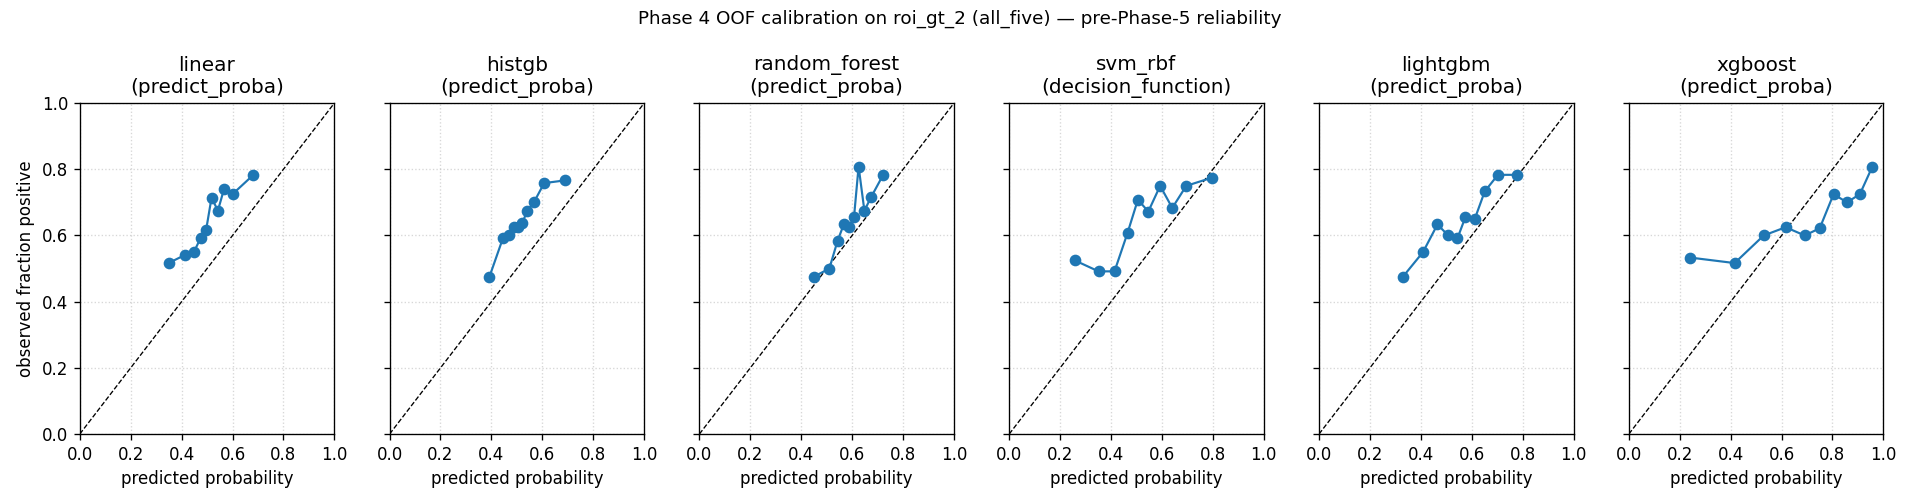

In [25]:
Image(filename=str(paths.REPORTS_FIGURES_DIR / 'phase4_calibration_pre.png'))

## H. Per-target winners

The winning family per target is the one with the best OOF
metric (AUC-ROC max for classification, RMSE min for
regression). Ties on the headline metric break to the
``standalone_positive_union`` matrix per the parsimony rule.
The winner per target is saved to
``data/processed/phase4_primary_model_<target>.joblib`` for
Phase 5 calibration and Phase 8 test evaluation.

In [26]:
import joblib
winners = pd.read_csv(paths.REPORTS_TABLES_DIR / 'phase4_winners.csv').set_index('target')
for target in ['log_roi', 'roi_gt_1', 'roi_gt_2']:
    path = paths.DATA_PROCESSED_DIR / f'phase4_primary_model_{target}.joblib'
    bundle = joblib.load(path)
    metric_name = 'RMSE' if target == 'log_roi' else 'AUC-ROC'
    oof_value = winners.loc[target, 'oof_metric']
    print(f"{target}: family={bundle['family']:14s} matrix={bundle['matrix']}")
    print(f"  best_params: {bundle['best_params']}")
    print(f"  OOF {metric_name}: {oof_value:.4f}")
    print()

log_roi: family=random_forest  matrix=standalone_positive_union_mpnet
  best_params: {'max_depth': None, 'min_samples_leaf': 20, 'n_estimators': 500}
  OOF RMSE: 1.3102

roi_gt_1: family=svm_rbf        matrix=standalone_positive_union_mpnet
  best_params: {'C': 3, 'gamma': 0.01}
  OOF AUC-ROC: 0.6353

roi_gt_2: family=xgboost        matrix=standalone_positive_union_mpnet
  best_params: {'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 5, 'reg_lambda': 1.0}
  OOF AUC-ROC: 0.6520



## I. Conclusion and bridge to Phase 5

TBD. Filled at end of phase with the headline result, the
primary-outcome decision, and the ensemble-work
recommendation for the planning conversation.

Phase 5 will:

* Read the per-target winner from
  ``data/processed/phase4_primary_model_*.joblib``.
* Apply conformal prediction (``mapie``) to produce
  calibrated prediction intervals on the 257-film
  calibration set.
* Add Platt scaling for SVM-RBF if it is the headline
  winner, per the calibration figure above.
* Validate empirical coverage at multiple confidence
  levels via reliability diagrams.

The methodology novelty contribution of the project is the
four-layer architecture, not single-model SOTA. Phase 4 has
identified the strongest feed for Layers 2 through 4; the
report frames this work accordingly.